In [2]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REFERENCE = Path("../data/antibacterial.fasta")
TRIAL = Path("../data/dbaasp_trial.ndjson")
FULL = Path("../data/dbaasp_raw.ndjson")

ALPHABET = "ACDEFGHIKLMNPQRSTVWY"
PKA_SIDE = {"K": 10.54, "R": 12.48, "H": 6.04, "D": 3.90, "E": 4.07, "C": 8.18, "Y": 10.46}
CATIONIC, ANIONIC = set("KRH"), set("DECY")
EISENBERG = {
    "A": 0.62, "R": -2.53, "N": -0.78, "D": -0.90, "C": 0.29,
    "Q": -0.85, "E": -0.74, "G": 0.48, "H": -0.40, "I": 1.38,
    "L": 1.06, "K": -1.50, "M": 0.64, "F": 1.19, "P": 0.12,
    "S": -0.18, "T": -0.05, "W": 0.81, "Y": 0.26, "V": 1.08,
}


def net_charge(seq, ph=7.4):
    q = 1.0 / (1.0 + 10 ** (ph - 9.69)) - 1.0 / (1.0 + 10 ** (2.34 - ph))
    for aa in seq:
        pka = PKA_SIDE.get(aa)
        if pka is None:
            continue
        if aa in CATIONIC:
            q += 1.0 / (1.0 + 10 ** (ph - pka))
        elif aa in ANIONIC:
            q -= 1.0 / (1.0 + 10 ** (pka - ph))
    return q


def moment(seq, delta=100.0):
    if not seq:
        return 0.0
    h = np.array([EISENBERG[a] for a in seq])
    ang = np.deg2rad(delta) * np.arange(len(seq))
    return float(np.abs((h * np.exp(1j * ang)).sum()) / len(seq))


def read_fasta(path):
    seqs, cur = [], []
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if cur:
                seqs.append("".join(cur))
                cur = []
        else:
            cur.append(line.upper())
    if cur:
        seqs.append("".join(cur))
    return seqs


def read_ndjson(path):
    out = []
    with path.open(encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if line:
                try:
                    out.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return out

In [3]:
refs = read_fasta(REFERENCE)
legal = [s for s in refs if set(s) <= set(ALPHABET) and 8 <= len(s) <= 50]

print(f"total sequences        {len(refs)}")
print(f"unique                 {len(set(refs))}")
print(f"legal alphabet+length  {len(legal)}  ({100 * len(legal) / len(refs):.1f}%)")
print(f"contain cysteine       {sum('C' in s for s in legal)}")

lengths = np.array([len(s) for s in refs])
print(f"\nlength: min {lengths.min()}  median {int(np.median(lengths))}  max {lengths.max()}")
print(f"over 50 residues: {(lengths > 50).sum()}")

total sequences        39448
unique                 39448
legal alphabet+length  39448  (100.0%)
contain cysteine       10425

length: min 8  median 18  max 50
over 50 residues: 0


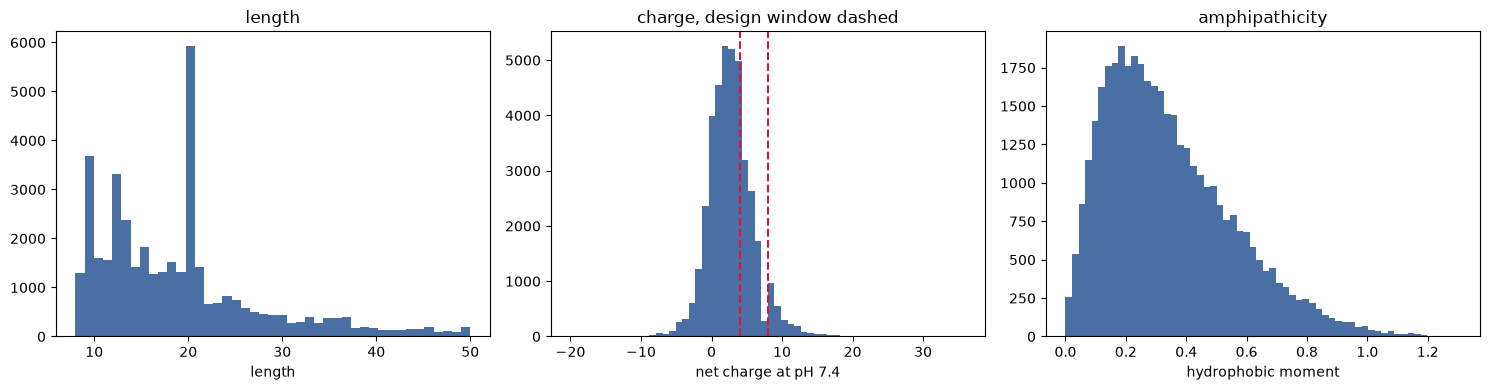

charge: median 2.85   inside [4, 8]: 23.5%
moment: median 0.303


In [4]:
charges = np.array([net_charge(s) for s in legal])
moments = np.array([moment(s) for s in legal])
legal_lengths = np.array([len(s) for s in legal])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(legal_lengths, bins=43, color="#4a6fa5")
axes[0].set_xlabel("length"); axes[0].set_title("length")
axes[1].hist(charges, bins=60, color="#4a6fa5")
axes[1].axvline(4, color="crimson", ls="--"); axes[1].axvline(8, color="crimson", ls="--")
axes[1].set_xlabel("net charge at pH 7.4"); axes[1].set_title("charge, design window dashed")
axes[2].hist(moments, bins=60, color="#4a6fa5")
axes[2].set_xlabel("hydrophobic moment"); axes[2].set_title("amphipathicity")
plt.tight_layout(); plt.show()

print(f"charge: median {np.median(charges):.2f}   inside [4, 8]: {100 * ((charges >= 4) & (charges <= 8)).mean():.1f}%")
print(f"moment: median {np.median(moments):.3f}")

In [5]:
source = FULL if FULL.exists() else TRIAL
records = read_ndjson(source)
print(f"{source.name}: {len(records)} records\n")

rec = next(r for r in records if r.get("targetActivities"))
print("top-level keys:")
print(sorted(rec.keys()))
print("\none targetActivities entry:")
print(json.dumps(rec["targetActivities"][0], indent=2)[:1200])

dbaasp_raw.ndjson: 13875 records

top-level keys:
['CTerminus', 'NTerminus', 'antibiofilmActivities', 'articles', 'cTerminus', 'complexity', 'coordinationBonds', 'dbaaspId', 'hemoliticCytotoxicActivities', 'id', 'interchainBonds', 'intrachainBonds', 'majorName', 'monomers', 'nTerminus', 'name', 'noteReference', 'opms', 'pdbs', 'physicoChemicalProperties', 'pubChem', 'sequence', 'sequenceLength', 'smiles', 'sourceGenes', 'structureModel', 'synergies', 'synthesisType', 'targetActivities', 'targetGroups', 'targetObjects', 'uniprots', 'unusualAminoAcids', 'url']

one targetActivities entry:
{
  "activity": 6.0,
  "activityMeasureGroup": {
    "description": "",
    "name": "IC50"
  },
  "activityMeasureValue": "IC50",
  "cfu": "1E5-5E5",
  "cfuGroup": {
    "name": "1E5 - 1E6"
  },
  "concentration": "6",
  "id": 7,
  "ionicStrength": "",
  "medium": {
    "description": "Mueller Hinton Broth",
    "name": "MHB"
  },
  "note": "",
  "peptideId": 10,
  "ph": "",
  "reference": "1",
  "saltT

In [6]:
# Which fields are objects rather than strings. The unit field is a dict,
# and treating it as a string silently discards every activity record.
shapes = Counter()
for r in records:
    for act in (r.get("targetActivities") or []):
        for key in ("unit", "targetSpecies", "activityMeasureGroup", "concentration", "medium"):
            shapes[(key, type(act.get(key)).__name__)] += 1

for (key, kind), n in sorted(shapes.items()):
    print(f"{key:24s} {kind:8s} {n}")

activityMeasureGroup     NoneType 7713
activityMeasureGroup     dict     103497
concentration            str      111210
medium                   NoneType 5177
medium                   dict     106033
targetSpecies            dict     111210
unit                     NoneType 7714
unit                     dict     103496


In [7]:
# Raw concentration strings. Censoring shows up here as > and < prefixes
# and as ranges, all of which need parsing rather than float() coercion.
raw = [str(a.get("concentration")) for r in records for a in (r.get("targetActivities") or [])]
print(f"{len(raw)} activity values\n")
print("non-numeric forms:")
for v, n in Counter(v for v in raw if not v.replace(".", "", 1).isdigit()).most_common(25):
    print(f"  {v[:40]:42s} {n}")

111210 activity values

non-numeric forms:
  NA                                         7710
  >100                                       3474
  >128                                       2360
  >64                                        1827
  >200                                       1407
  >50                                        1186
  >256                                       758
  >512                                       643
  >32                                        523
  >500                                       428
  >10                                        372
  2-4                                        336
  >250                                       320
  4-8                                        313
  >40                                        299
  8-16                                       297
  >80                                        291
  >25                                        288
  >30                                        264
  16-32             

In [8]:
# Target species coverage decides whether the Gram-positive and Gram-negative
# heads can be trained separately, and whether an MDR head is viable at all.
species = Counter()
for r in records:
    for a in (r.get("targetActivities") or []):
        t = a.get("targetSpecies")
        t = t.get("name") if isinstance(t, dict) else t
        if t:
            species[str(t)] += 1

print(f"{len(species)} distinct species\n")
for name, n in species.most_common(25):
    print(f"  {name[:50]:52s} {n}")

6338 distinct species

  Escherichia coli ATCC 25922                          5454
  Pseudomonas aeruginosa ATCC 27853                    3204
  Staphylococcus aureus ATCC 25923                     3187
  Staphylococcus aureus                                2078
  Staphylococcus aureus ATCC 29213                     1796
  Escherichia coli                                     1626
  Pseudomonas aeruginosa                               1344
  Pseudomonas aeruginosa PAO1                          1158
  Enterococcus faecalis ATCC 29212                     1149
  Candida albicans                                     895
  Staphylococcus epidermidis ATCC 12228                870
  Candida albicans ATCC 10231                          862
  Salmonella enterica subsp. enterica serovar Typhim   778
  Staphylococcus aureus ATCC 43300                     713
  Klebsiella pneumoniae                                708
  Bacillus subtilis                                    691
  Bacillus subtilis ATCC

In [9]:
def name_of(v):
    return (v.get("name") if isinstance(v, dict) else v) or ""

dbaasp_seqs = {
    r["sequence"].strip().upper()
    for r in records
    if r.get("sequence") and name_of(r.get("complexity")).lower() == "monomer"
}
dbaasp_seqs = {s for s in dbaasp_seqs if set(s) <= set(ALPHABET) and 8 <= len(s) <= 50}
ref_set = set(legal)

overlap = dbaasp_seqs & ref_set
print(f"usable DBAASP monomers   {len(dbaasp_seqs)}")
print(f"also in reference set    {len(overlap)}")
if dbaasp_seqs:
    print(f"fraction already known   {100 * len(overlap) / len(dbaasp_seqs):.1f}%")

usable DBAASP monomers   9346
also in reference set    8614
fraction already known   92.2%


In [10]:
from collections import Counter
print(Counter(type(r.get("complexity")).__name__ for r in records))
print(Counter(str(r.get("complexity")) for r in records).most_common(10))
print()
blank = sum(1 for r in records if not r.get("sequence"))
print(f"records with empty sequence: {blank} / {len(records)}")
print("example sequence:", repr(records[0].get("sequence"))[:80])

Counter({'dict': 13875})
[("{'name': 'Monomer'}", 13520), ("{'description': '', 'name': 'Multimer'}", 180), ("{'name': 'Multi-Peptide'}", 175)]

records with empty sequence: 355 / 13875
example sequence: 'LFIFFF'


In [12]:
from collections import Counter
import json
from pathlib import Path

measures, unmatched = Counter(), Counter()
for r in records:
    for a in (r.get("targetActivities") or []):
        m = a.get("activityMeasureGroup")
        m = m.get("name") if isinstance(m, dict) else m
        measures[str(m)] += 1

        t = a.get("targetSpecies")
        t = t.get("name") if isinstance(t, dict) else t

        if str(m).upper().replace(" ", "") in {"MIC", "MIC50", "MIC90"} and t:
            unmatched[str(t)] += 1

print("measure types:")
for k, v in measures.most_common(15):
    print(f"  {k:28s} {v}")

measure types:
  MIC                          78560
  None                         7713
  MBC                          7483
  IC50                         6602
  LC                           1618
  MIC90                        1071
  MIC50                        815
  MFC                          732
  EC50                         605
  MEC                          535
  LC50                         508
  IC50 REP                     472
  LD50                         415
  90-100% Inhibition           391
  50% Cell death               273


In [14]:
import numpy as np, pandas as pd, sys
sys.path.insert(0, "src")
from amp_design.features import hydrophobic_moment, net_charge
from pathlib import Path

activity_path = Path("../data/activity_wide.csv")
if not activity_path.exists():
    activity_path = Path("data/activity_wide.csv")

w = pd.read_csv(activity_path, index_col=0)
w.index = w.index.astype(str)
mic = w[[c for c in ("gram_positive","gram_negative") if c in w]].min(axis=1)
d = pd.DataFrame({"hc50": w["hc50"], "mic": mic}).dropna()
d = d[[("C" not in s) for s in d.index]]
d["moment"] = [hydrophobic_moment(s) for s in d.index]
d["charge"] = [net_charge(s) for s in d.index]

print("raw correlations with HC50")
print(d[["moment","charge","mic"]].corrwith(d["hc50"], method="spearman"))

# partial: residualise HC50 and moment on MIC, then correlate
import numpy.polynomial.polynomial as P
for v in ("moment","charge"):
    rh = d["hc50"] - np.poly1d(np.polyfit(d["mic"], d["hc50"], 1))(d["mic"])
    rv = d[v]    - np.poly1d(np.polyfit(d["mic"], d[v],    1))(d["mic"])
    print(f"partial spearman HC50~{v} | MIC: {pd.Series(rh).corr(pd.Series(rv), method='spearman'):.3f}")

raw correlations with HC50
moment    0.035552
charge   -0.014729
mic       0.300666
dtype: float64
partial spearman HC50~moment | MIC: 0.060
partial spearman HC50~charge | MIC: 0.077


In [15]:
u = d[w.loc[d.index, "hc50_censor"].fillna(0) == 0] if "hc50_censor" in w else d
print(len(u), "uncensored")
print(u[["moment","charge","mic"]].corrwith(u["hc50"], method="spearman"))

4347 uncensored
moment   -0.016631
charge   -0.018176
mic       0.269875
dtype: float64


In [16]:
import sys; sys.path.insert(0, "src")
from amp_design.features import partitioning_energies

for k in ("dg_interface", "dg_octanol", "interfacial_preference"):
    d[k] = [partitioning_energies(s)[k] for s in d.index]

print(d[["dg_interface","dg_octanol","interfacial_preference"]].corrwith(d["hc50"], method="spearman"))

dg_interface              0.091893
dg_octanol                0.056436
interfacial_preference    0.018751
dtype: float64


In [18]:
import json
from collections import Counter
from pathlib import Path

vals, cells = Counter(), Counter()
for r in records:
    for a in (r.get("hemoliticCytotoxicActivities") or []):
        vals[str(a.get("concentration"))] += 1
        t = a.get("targetCell")
        cells[str(t.get("name") if isinstance(t, dict) else t)] += 1

print("most common HC50 values:"); [print(f"  {k:12s} {v}") for k, v in vals.most_common(15)]
print("\ntarget cells:"); [print(f"  {k[:40]:42s} {v}") for k, v in cells.most_common(10)]

most common HC50 values:
  NA           1318
  100          1244
  50           740
  200          416
  250          284
  25           280
  64           276
  128          270
  150          264
  >100         254
  >200         209
  10           208
  256          172
  >500         165
  32           158

target cells:
  Human erythrocytes                         7625
  Rabbit erythrocytes                        468
  Horse erythrocytes                         455
  Sheep erythrocytes                         437
  Rat erythrocytes                           414
  Mouse erythrocytes                         359
  Human keratinocytes HaCat                  320
  Human embryonic kidney HEK293 cells        259
  Vero cells                                 155
  Human umbilical vein endothelial cells H   140


[None, None, None, None, None, None, None, None, None, None]